TensorFlow Version: 2.21.0

--- Generating Dummy Data ---
Tabular training shape: (400, 4)
Image training shape: (400, 64, 64, 3)
Target training shape: (400,)

--- Building Multimodal Model ---

--- Training Model ---
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - loss: 9936090.0000 - mae: 2790.3770 - val_loss: 7882845.5000 - val_mae: 2445.7935
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 6496469.0000 - mae: 2150.4121 - val_loss: 2156892.2500 - val_mae: 1225.8914
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 2840418.7500 - mae: 1413.7965 - val_loss: 2015568.7500 - val_mae: 1218.4199
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 2343574.7500 - mae: 1315.8331 - val_loss: 1985448.2500 - val_mae: 1202.2361
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 2170346.5000 - mae: 1278.7604 - val_loss: 2201127.0000 - val_mae: 1269.5807
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 2251089.0000 - mae: 1285.0999 - val_loss: 1913

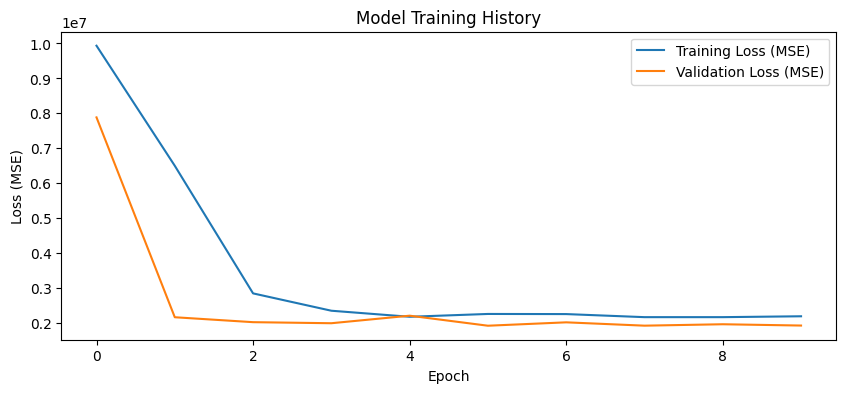

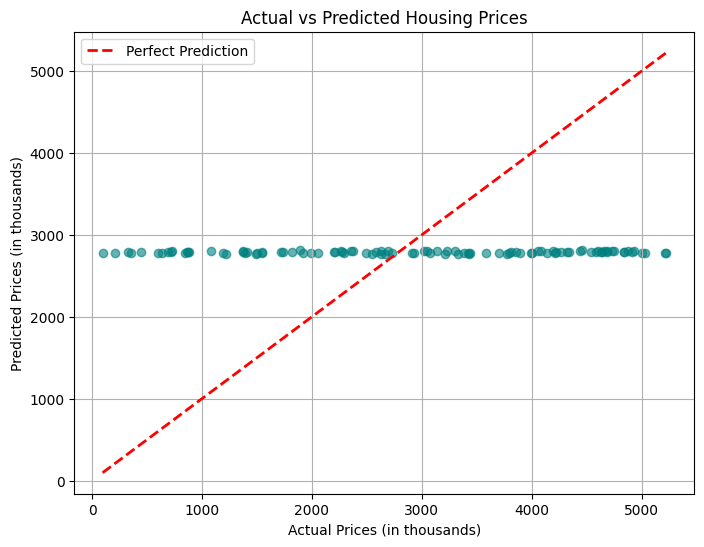

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, concatenate
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

#2. Dataset Loading & Preprocessing (Using Dummy Data)

print("\n--- Generating Dummy Data ---")
num_samples = 500

# Tabular Data: 4 features (e.g., square footage, bedrooms, bathrooms, age)
X_tabular = np.random.rand(num_samples, 4) * 100 
scaler = StandardScaler()
X_tabular_scaled = scaler.fit_transform(X_tabular)

# Image Data: 500 images of size 64x64 with 3 color channels (RGB)
X_images = np.random.rand(num_samples, 64, 64, 3)

# Target Variable: Housing Prices (in thousands)
y_prices = (X_tabular[:, 0] * 3.5) + (X_tabular[:, 1] * 50) + np.random.normal(0, 20, num_samples)

# Train-Test Split (80% training, 20% testing)
X_tab_train, X_tab_test, X_img_train, X_img_test, y_train, y_test = train_test_split(
    X_tabular_scaled, X_images, y_prices, test_size=0.2, random_state=42
)

print(f"Tabular training shape: {X_tab_train.shape}")
print(f"Image training shape: {X_img_train.shape}")
print(f"Target training shape: {y_train.shape}")

#3. Model Development & Training

print("\n--- Building Multimodal Model ---")

# Branch 1: Convolutional Neural Network (CNN) for Image Feature Extraction
image_input = Input(shape=(64, 64, 3), name="image_input")
x = Conv2D(32, (3, 3), activation='relu')(image_input)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)
image_features = Dense(64, activation='relu')(x) # High-level image features

# Branch 2: Dense Network for Tabular Data
tabular_input = Input(shape=(4,), name="tabular_input")
y = Dense(32, activation='relu')(tabular_input)
tabular_features = Dense(16, activation='relu')(y) # High-level tabular features

# Feature Fusion: Combine image features with tabular data
combined = concatenate([image_features, tabular_features])

# Final Regression Layers for Price Prediction
z = Dense(64, activation='relu')(combined)
z = Dense(32, activation='relu')(z)
output = Dense(1, name="price_output")(z) 

# Build and compile the model
model = Model(inputs=[image_input, tabular_input], outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model using both modalities
print("\n--- Training Model ---")
history = model.fit(
    x={"image_input": X_img_train, "tabular_input": X_tab_train},
    y=y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

#4. Evaluation with Relevant Metrics

print("\n--- Evaluating Model ---")

# Generate predictions on the test set
predictions = model.predict(
    {"image_input": X_img_test, "tabular_input": X_tab_test}
)

# Calculate MAE and RMSE
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}\n")

# Display a few sample predictions vs actual prices
print("Sample Predictions vs Actual Prices (in thousands):")
print("-" * 55)
for i in range(5):
    predicted_price = predictions[i][0]
    actual_price = y_test[i]
    difference = abs(predicted_price - actual_price)
    print(f"House {i+1}: Predicted = ${predicted_price:.2f}k | Actual = ${actual_price:.2f}k | Diff = ${difference:.2f}k")

#5. Visualizations

# 1. Plot Training and Validation Loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Training History')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# 2. NEW: Plot Actual vs Predicted Housing Prices
plt.figure(figsize=(8, 6))
# Scatter plot of actual vs predicted
plt.scatter(y_test, predictions, alpha=0.6, color='teal')

# Draw a red diagonal line representing perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

plt.title('Actual vs Predicted Housing Prices')
plt.xlabel('Actual Prices (in thousands)')
plt.ylabel('Predicted Prices (in thousands)')
plt.legend()
plt.grid(True)
plt.show()